In [6]:
df = pd.read_csv("eternal_stock.csv")

In [5]:
import pandas as pd

In [7]:
df.head()

,DATE,SERIES,OPEN,HIGH,LOW,PREV. CLOSE,LTP,CLOSE,VWAP,52W H,52W L,VOLUME,VALUE,NO. OF TRADES
0,27-03-2026,EQ,237.55,239.14,232.40,242.18,232.71,233.17,235.75,368.45,194.8,38767229,9.139183e+09,239888
1,25-03-2026,EQ,242.00,244.50,240.01,237.94,241.97,242.18,242.25,368.45,194.8,64768357,1.569043e+10,295692
2,24-03-2026,EQ,231.00,240.29,230.81,226.96,238.05,237.94,235.55,368.45,194.8,63944923,1.506212e+10,292622
3,23-03-2026,EQ,227.90,231.40,224.21,232.29,226.86,226.96,227.03,368.45,194.8,71121843,1.614700e+10,507043
4,20-03-2026,EQ,230.10,236.70,230.10,228.74,233.00,232.29,232.82,368.45,194.8,55775443,1.298570e+10,299068


C:\Users\abdul\AppData\Local\Temp\ipykernel_43616\504000938.py:4: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['DATE'] = pd.to_datetime(df['DATE'])


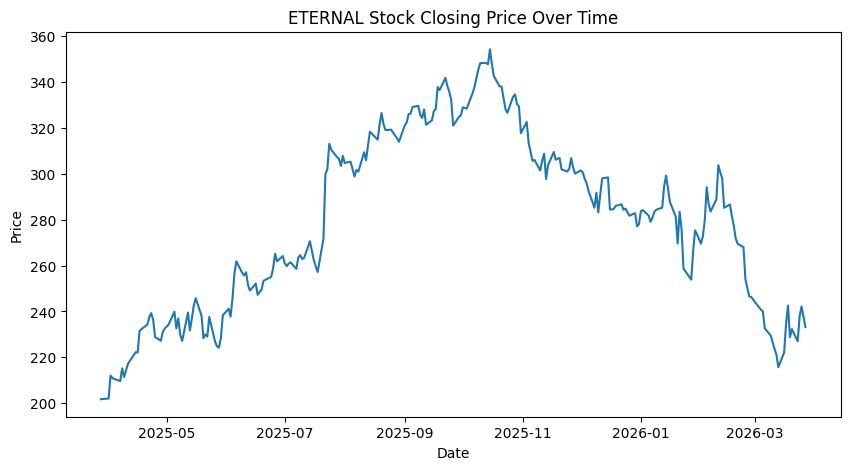

In [8]:
import matplotlib.pyplot as plt

# Convert date properly
df['DATE'] = pd.to_datetime(df['DATE'])

# Sort data
df = df.sort_values('DATE')

# Plot graph
plt.figure(figsize=(10,5))
plt.plot(df['DATE'], df['CLOSE'])

plt.title("ETERNAL Stock Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price")

plt.show()

In [9]:
df.isnull().sum()

DATE              0
SERIES            0
OPEN              0
HIGH              0
LOW               0
PREV. CLOSE       0
LTP               0
CLOSE             0
VWAP              0
52W H             0
52W L             0
VOLUME            0
VALUE             0
NO. OF  TRADES    0
dtype: int64

In [10]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['CLOSE'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -1.7906350960301745
p-value: 0.38512092057318


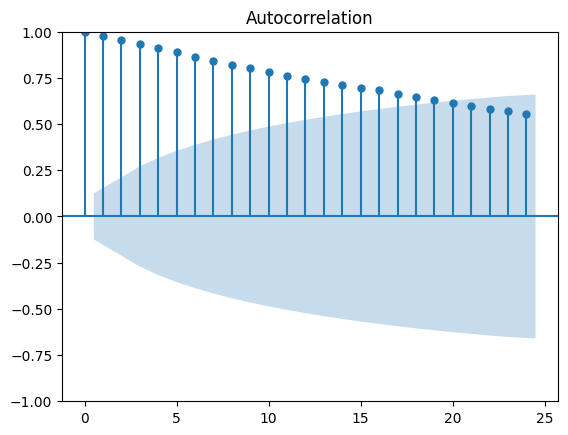

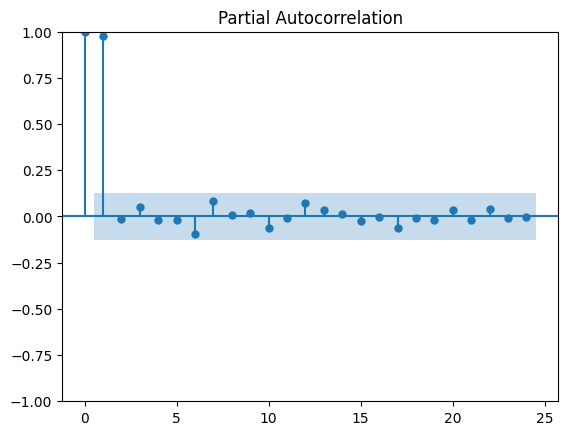

In [11]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

plot_acf(df['CLOSE'])
plot_pacf(df['CLOSE'])

plt.show()

In [12]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(df['CLOSE'], order=(1,1,1))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  CLOSE   No. Observations:                  247
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -786.495
Date:                Sat, 28 Mar 2026   AIC                           1578.989
Time:                        19:28:48   BIC                           1589.505
Sample:                             0   HQIC                          1583.224
                                - 247                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2722      0.838     -0.325      0.745      -1.915       1.371
ma.L1          0.3357      0.815      0.412      0.681      -1.262       1.934
sigma2        35.0359      2.615     13.399      0.0

In [13]:
forecast = model_fit.forecast(steps=30)

print(forecast)

-1     232.605219
-2     232.758926
-3     232.717094
-4     232.728479
-5     232.725380
-6     232.726224
-7     232.725994
-8     232.726057
-9     232.726040
-10    232.726044
-11    232.726043
-12    232.726043
-13    232.726043
-14    232.726043
-15    232.726043
-16    232.726043
-17    232.726043
-18    232.726043
-19    232.726043
-20    232.726043
-21    232.726043
-22    232.726043
-23    232.726043
-24    232.726043
-25    232.726043
-26    232.726043
-27    232.726043
-28    232.726043
-29    232.726043
-30    232.726043
Name: predicted_mean, dtype: float64


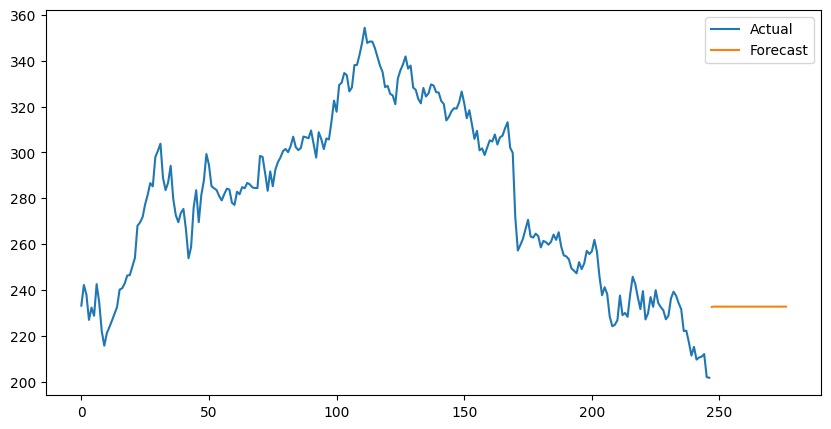

In [14]:
plt.figure(figsize=(10,5))

plt.plot(df['CLOSE'], label='Actual')
plt.plot(range(len(df), len(df)+30), forecast, label='Forecast')

plt.legend()
plt.show()